<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Mecanica-de-medios-continuos/MCON_Tarea2_Atm%C3%B3sfera_Emp%C3%ADrica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p>
<img src="https://drive.google.com/uc?id=1ZHUKcwzA5c-PKUwoGmBG3TsHk6TmZ-Y0" align="left" width="250">
</p>
<p>
<h1><b><center>Mecánica de Medios Continuos</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Tarea 2</center></b><h2>
<h3><b><center>Atmósfera Empírica</center></b><h3>
<h5><center><b>Asignada</b>: 6 de Marzo de 2024</center><h5>
<h5><center><b>Entrega</b>: 21 de Marzo de 2024</center><h5>
</p>

<hr/>
<b>Nombre</b>: Juan Manuel Cardenas
<br/>
<b>Cédula</b>: 1002587562
<br/>
<b>Última actualización</b>:21/3/24
<hr/>

In [ ]:
# Instalacion de paquetes
!pip install -q nrlmsise00 # modelo atmosferico empirico
!pip install -qU 'nrlmsise00[dataset]'
!pip install -q spaceweather

!pip install -Uq mendeleev # masas atomicas de elementos
!pip install -Uq cartopy # mapas cartograficos
!pip install -q celluloid # animaciones

In [ ]:
# Librerias
import numpy as np
import matplotlib.pyplot as plt
import astropy.constants as astro_cts
import scipy.constants as cts
import cartopy.crs as ccrs # cartografia

from tqdm import tqdm # control de tiempos
from mendeleev import element # peso atomico de elementos
from scipy.signal import argrelextrema as extrem # extremos relativos
from scipy.optimize import minimize # minimizacion de chi2
from IPython.display import HTML # visualizar animacion 2d
from celluloid import Camera # animacion 2d

# funciones atmosfera empirica
from nrlmsise00.dataset import msise_4d
from datetime import datetime
import spaceweather as sw
sw.update_data()
# NRLMSISE-00 usa datos de clima espacial (tienen que actualizarse)

plt.style.use('seaborn-v0_8-dark-palette')

/usr/local/lib/python3.10/dist-packages/nrlmsise00/dataset/__init__.py:27: UserWarning: The xarray 4d interface is experimental.
  warn("The xarray 4d interface is experimental.", UserWarning)


### **Objetivo**:

El objetivo de esta tarea es comparar los distintos modelos de atmósferas vistos en el curso, frente al modelo de atmósfera empírica [NRLMSISE-00](https://en.wikipedia.org/wiki/NRLMSISE-00) (_US Naval Research Laboratory mass spectrometer and incoherent scatter radar_). Este modelo puede darnos información de la atmósfera en distintas ubicaciones en la Tierra, épocas del año, horas del día e incluso épocas del ciclo solar.
<br><br><br>


### **Datos atmosfericos empiricos**<br>

1. Obtener los datos de la atmósfera desde la superficie hasta 100 km en una ubicación, fecha y hora específica cada 50 metros. Para ello puede usar el día y lugar de nacimiento. Asuma para la hora de nacimiento las 12 m (medio día). Para la ubicación use la ciudad del mundo que siempre ha soñado visitar o que más ha disfrutado visitar.

se tomaron 2 sitios para analizar en la tierra, el deseado en una region relativamente central del globo en francia, y el segundo en un caso particular cerca al polo sur que genera inconvenientes como se verá mas adelante.


In [ ]:
# alturas
hmax = 100e3 # [m]
zs = np.arange(0, hmax, 50) # [m]

# coordenadas, provenza francia (45 N 6E) y extremo (-90,-180)
lat = [45,-90]
lon = [6,-180]

# objeto de datos atmosferico
ds = msise_4d( datetime(2000,4,23,12,0,0), zs/1e3, lat, lon )

### **Variables Termodinamicas empiricas: GI**<br>

2. Usando los datos de composición de la atmósfera, calcule la presión atmosférica a cada altura. Asuma para ello la ecuación de estado de gas ideal.  Haga gráficos de temperatura, densidad y presión con la altura, usando la convención en ciencias atmosféricas de poner la altura en el eje y.

In [ ]:
# parametros atmosfera terrestre
Ro = astro_cts.R_earth.value # [m]
R = cts.R # [J/(mol*K)]
atm = 101.325e3 # [Pa]
po = 1*atm
ρo = 1.225      # [kg/m^3]
go = 9.80665    # [m/s^2]
ho = po/(ρo*go) # escala vertical

In [ ]:
# calculo Mmol empirico
species = [
    dict(name='N2',Mmol=2*element('Nitrogen').atomic_weight),
    dict(name='O2',Mmol=2*element('Oxygen').atomic_weight),
    dict(name='Ar',Mmol=1*element('Argon').atomic_weight),
    dict(name='N',Mmol=1*element('Nitrogen').atomic_weight),
    dict(name='O',Mmol=1*element('Oxygen').atomic_weight),
    dict(name='H',Mmol=1*element('Hydrogen').atomic_weight),]

ns = np.zeros(len(species)) # densidad masa?
ms = np.zeros(len(species)) # masa

for i,specie in enumerate(species):
  ns[i] = np.array(ds[specie['name']]).flatten()[-1]
  ms[i] = specie['Mmol']*ns[i]

n = ns.sum()
Mmol = ms.sum()/n*1e-3

In [ ]:
# Variables termodinamicas empiricas (con GI)
ρs_emp = np.array(ds["rho"])[:,:,0,0].flatten()*1e3 # densidad [kg/m^3]
Ts_emp = np.array(ds["Talt"])[:,:,0,0].flatten() # temperatura [k]
p_emp = (R/Mmol)*ρs_emp*Ts_emp # presion [Pa]

Perfiles empiricos $z$ vs $(T,p,\rho)$

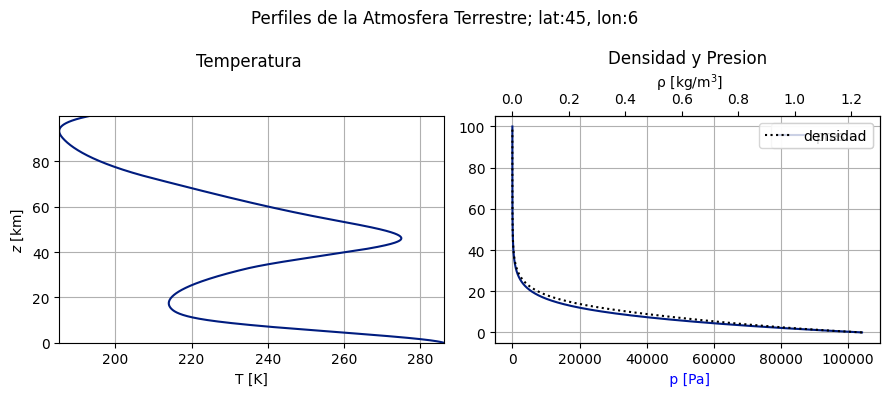

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(9,4))
fig.suptitle(f'Perfiles de la Atmosfera Terrestre; lat:{lat[0]}, lon:{lon[0]}')

ax[0].plot(Ts_emp, zs/1e3)
ax[0].set_title("Temperatura \n\n")
ax[0].set_ylabel(r"$z$ [km]")
ax[0].set_xlabel(r"T [K]")
ax[0].grid()
ax[0].margins(0)

ax[1].plot(p_emp, zs/1e3, label="presion")
ax[1].set_title(r"Densidad y Presion")
ax[1].set_xlabel(r" p [Pa]", color='b')
ax[1].legend()
ax[1].grid()
axd = ax[1].twiny()
axd.plot(ρs_emp, zs/1e3, 'k:', label='densidad')
axd.set_xlabel(r" ρ [kg/m$^3$]")
axd.legend()

fig.tight_layout()

### **Equilibrio hidrostatico atmosfera Terrestre**

3. Evalúe si en la atmósfera calculada hay equilibrio hidrostático, es decir, si se cumple a cada altura la condición:

$$
\frac{dp}{dz} = -\rho(z) g(z)
$$

Use valores de la aceleración de la gravedad que varíen con la altura.


$$g(z) = \frac{G M}{(R+z)^2} = \frac{g_0}{(1+z/R)^2}$$

In [ ]:
# funcion gravedad variable
g = lambda z: go/(1+z/R)**2

# ecuacion equilibrio hidrostatico
dpdz = np.diff(p_emp) / np.diff(zs) # lado izquierdo
ρg = ρs_emp * g(zs + Ro) # lado derecho (desde superficie)

In [ ]:
def calcular_derivada(p, z):
    dp_dz = np.zeros_like(p) #  arreglo para las derivadas

    # derivada usando diferencias centrales
    for i in range(1, len(p) - 1):
        dp_dz[i] = (p[i+1]-p[i-1]) / (z[i+1]-z[i-1])

    # diferencia hacia adelante para el primero y hacia atras para el ultimo
    dp_dz[0] = (p[1]-p[0]) / (z[1]-z[0])
    dp_dz[-1] = (p[-1]-p[-2]) / (z[-1]-z[-2])

    return dp_dz

deriv = calcular_derivada(p_emp, zs)

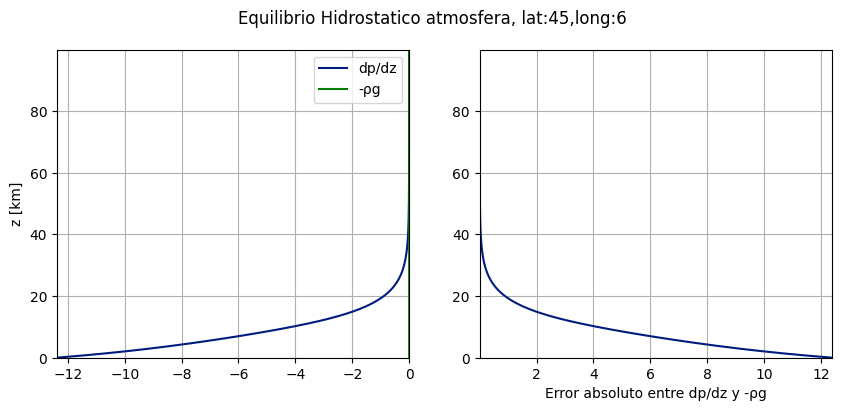

In [ ]:
# GRAFICA
fig, ax = plt.subplots(1,2,figsize=(10,4))
fig.suptitle(f'Equilibrio Hidrostatico atmosfera, lat:{lat[0]},long:{lon[0]}')

ax[0].plot(deriv, zs/1e3, label='dp/dz')
ax[0].plot(-ρg, zs/1e3, 'g', label='-ρg')
ax[0].set_ylabel("z [km]")
ax[0].legend()
ax[0].grid()
ax[0].margins(0)

error = np.abs(deriv-(-ρg))
ax[1].plot(error, zs/1e3)
ax[1].set_xlabel("Error absoluto entre dp/dz y -ρg")
ax[1].margins(0)
ax[1].grid()

### **Capas Atmosfericas**

4. Llamamos **tropopausa** a la altura de la atmósfera en la que la temperatura deja de disminuir con la altura. <br>

* Encuentre la altura de la **tropopausa** para el sitio y lugar elegido. <br>
* A la capa de la atmósfera debajo de esa altura se la llama la **troposfera**.

usando la funcion `argrelaextrema` de `scipy` se pueden encontrar los minimos y maximos relativos de una funcion discreta, entonces, viendo la grafica, la tropopausa empieza en el primer minimo local, que es cuando la temperatura deja de disminuir, las otras capas tambien se pueden deducir de la observacion de la curva de temperatura, y se definieron de la siguiente forma:

Uso de `argrelaextrema` de `scipy` Recuperado de: https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.argrelextrema.html

In [ ]:
# cambios de temperatura
i_max = extrem( Ts_emp, np.greater)[0] # indice max
z_max = zs[i_max][0]

i_min = extrem( Ts_emp, np.less)[0]    # index min
z_min = zs[i_min]

z_1 = z_min[0] # altrua tropopausa
z_2 = z_max    # altrua estratopausa
z_3 = z_min[1] # altrua mesopausa

Para generalizar, y enfocandose solo en la tropopausa, usando las lineas anteriores se crearon funciones para el calculo de la altura de la tropopausa dada la temperatura y la altura z, se definieron 2 metodos:
el primero (metodo 1): trató de encontrar el primer minimo del arreglo de temperaturas con la funcion argrelaextrema, que coincide con la definicion de tropopausa, altura a partir de la cual la temperatura deja de descender, sin embargo, como se verá mas adelante, este metodo genera una anomalia en la region sur de la tierra, donde la altura de la troposfera incrementa por encima de 20km, por ejemplo este caso se puede observar en lat=-90, long=-180

por lo que se consideró tambien crear el metodo 2, el cual involucraba el primer maximo de la derivada central de la temperatura.

In [ ]:
# criterios para encontrar tropopausa

def tropopausa_T(T, z): # metodo1: usando minimos de temperatura
  i_min = extrem( T, np.less)[0]  # indices de minimos
  z_min = z[i_min]                # z donde T es minimo
  return z_min[0] # primer z donde T es minimo


def tropopausa_dT(T, z): #  metodo2: usando maximos de cambios de temperatura
  dT = calcular_derivada(T, z) # derivada de T
  i_max = extrem( dT, np.greater)[0]  # indices de maximos
  z_max = z[i_max] # z donde dT es max
  return z_max[0] # primer z donde dT es max

**perfil de temperatura en una region relativamente cercana a la ecuatorial**

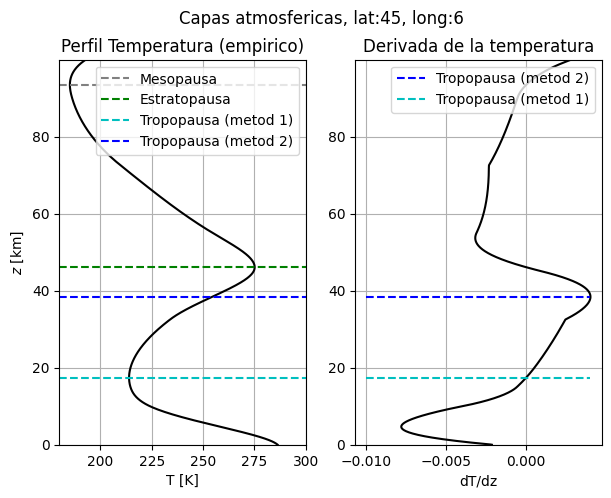

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(7,5))
fig.suptitle(f'Capas atmosfericas, lat:{lat[0]}, long:{lon[0]}')

# perfil de temperatura
ax[0].plot(Ts_emp, zs/1e3, 'k')
ax[0].hlines(z_3/1e3, 180,300, label='Mesopausa',
             linestyle='--',colors ='gray')
ax[0].hlines(z_2/1e3, 180,300, label='Estratopausa',
             linestyle='--',colors ='g')
ax[0].hlines(tropopausa_T(Ts_emp, zs)/1e3, 180,300,
             label='Tropopausa (metod 1)', linestyle='--',colors ='c')
ax[0].hlines(tropopausa_dT(Ts_emp, zs)/1e3, 180,300,
             label='Tropopausa (metod 2)', linestyle='--',colors ='b')
ax[0].set_title(r"Perfil Temperatura (empirico)")
ax[0].set_ylabel(r"$z$ [km]")
ax[0].set_xlabel(r"T [K]")
ax[0].set_xlim(180, 300)
ax[0].set_ylim(0, zs[-1]/1e3)
ax[0].legend()
ax[0].grid()


# derivada dde la temperatura
ax[1].plot(calcular_derivada(Ts_emp, zs), zs/1e3, 'k')
ax[1].hlines(tropopausa_dT(Ts_emp, zs)/1e3, -0.010,0.004,
             label='Tropopausa (metod 2)', linestyle='--',colors ='b')
ax[1].hlines(tropopausa_T(Ts_emp, zs)/1e3, -0.010,0.004 ,
             label='Tropopausa (metod 1)', linestyle='--',colors ='c')

ax[1].set_title(r"Derivada de la temperatura")
ax[1].set_xlabel(r"dT/dz")
ax[1].set_ylim(0, zs[-1]/1e3)
ax[1].legend()
ax[1].grid()

de la grafica se observa que el metodo mas coherente con la definicion de la altura de la tropopausa es el metodo 1. no obstante para coordenadas cercanas al polo sur, esta curva de temperatura genera un nuevo cambio en la pendiente antes de que la temperatura deje de descender, el metodo 2 es apto para encontrar este caso del cambio de la pendiente.

**perfil de temperatura en una region del polo sur**

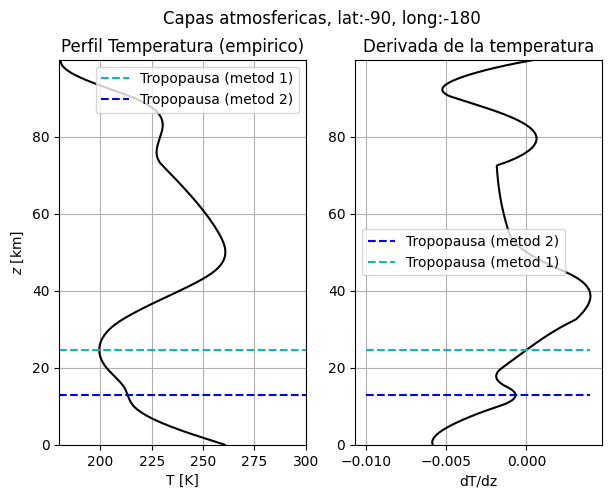

In [ ]:
Ts_emp = np.array(ds["Talt"])[:,:,1,1].flatten() # temperatura [k]

fig, ax = plt.subplots(1,2,figsize=(7,5))
fig.suptitle(f'Capas atmosfericas, lat:{lat[1]}, long:{lon[1]}')

# perfil de temperatura
ax[0].plot(Ts_emp, zs/1e3, 'k')
ax[0].hlines(tropopausa_T(Ts_emp, zs)/1e3, 180,300,
             label='Tropopausa (metod 1)', linestyle='--',colors ='c')
ax[0].hlines(tropopausa_dT(Ts_emp, zs)/1e3, 180,300,
             label='Tropopausa (metod 2)', linestyle='--',colors ='b')
ax[0].set_title(r"Perfil Temperatura (empirico)")
ax[0].set_ylabel(r"$z$ [km]")
ax[0].set_xlabel(r"T [K]")
ax[0].set_xlim(180, 300)
ax[0].set_ylim(0, zs[-1]/1e3)
ax[0].legend()
ax[0].grid()

# derivada dde la temperatura
ax[1].plot( calcular_derivada(Ts_emp, zs), zs/1e3, 'k')
ax[1].hlines(tropopausa_dT(Ts_emp, zs)/1e3, -0.010,0.004,
             label='Tropopausa (metod 2)', linestyle='--',colors ='b')
ax[1].hlines(tropopausa_T(Ts_emp, zs)/1e3, -0.010,0.004 ,
             label='Tropopausa (metod 1)', linestyle='--',colors ='c')

ax[1].set_title(r"Derivada de la temperatura")
ax[1].set_xlabel(r"dT/dz")
ax[1].set_ylim(0, zs[-1]/1e3)
ax[1].legend()
ax[1].grid()

para estas bajas latitudes se observa este cambio de pendiente de la temperatura en la troposfera, esta es la razon por la que se genera la anomalia que se muestra en el siguiente punto por el metodo 1 para la altura de la tropopausa.

### **Mapa de la altura de la Tropopausa**

5. Haga un gráfico de contornos sobre un mapa (use el código de ejemplo mostrado al final del enunciado) en el que muestre la altura de la troposfera como función de la longitud y la latitud. Observe.
* Haga una animación mostrando la temperatura en la superficie de la Tierra a lo largo de 1 día.


En este caso, como se desea mapear la altura de la troposfera, se considerará un nuevo arreglo de altura con limite de $40$km, region que pertenece a la estratosfera. Esto con fines de eficiencia en cuanto al tiempo de computo, para evitar calcular sobre alturas en las cuales se descarta que podria estar la tropopausa.

In [ ]:
# latitudes maximas
lats = np.linspace(-90, 90, 15)
lons = np.linspace(-180, 180, 15)
LONS, LATS = np.meshgrid(lons, lats) # malla
l = len(lons) # tamaño del arreglo de longitudes

iterando sobre todo el globo; primero con un ciclo sobre las latitudes, y aprovechando el hecho de que el objeto atmosferico `msise_4d()` permite pasar una lista de valores de longitudes para una sola latitud (y viceversa), se le pasaron las coordenadas de esta forma para facilitar la recopilacion de datos de la altura (que debian tener un shape igual al del objeto `LONS`, que se verá mas adelante para graficar los datos en el mapa cartografico) usando un for implicito para las longitudes.



In [ ]:
tropos1 = [] # altura tropopausa metod1
tropos2 = [] # altura tropopausa metod2
z = np.arange(0, 40e3, 50) # [m]


for i,lat_i in tqdm(enumerate(lats)): # sobre latitudes

  # objeto atmosferico
  dsi = msise_4d( datetime(2000,4,23,12,0,0), z/1e3, lat_i, lons )

  # tropopausa
  tropos1.append([ tropopausa_T(np.array(dsi.Talt)[:,:,:,j].flatten(),z) \
                  for j in range(l)])

  tropos2.append([ tropopausa_dT(np.array(dsi.Talt)[:,:,:,j].flatten(),z) \
                  for j in range(l)])


tropos1 = np.array(tropos1) # metodo 1
tropos2 = np.array(tropos2) # metodo 2

15it [00:38,  2.59s/it]


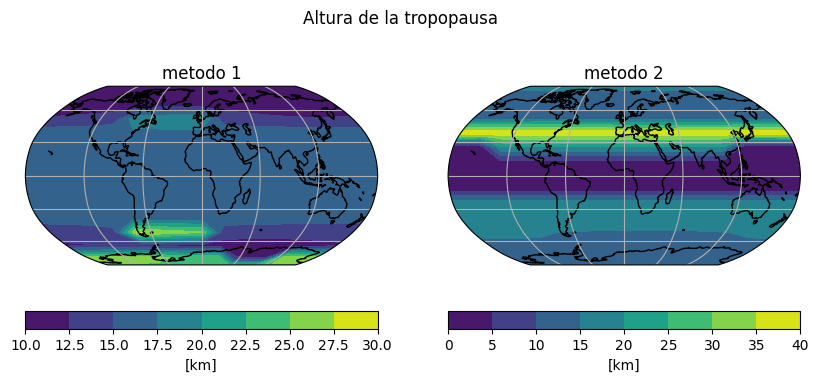

In [ ]:
# mapa cartografico
fig, ax = plt.subplots(1,2,figsize=(10,4),
                       subplot_kw={'projection':ccrs.Robinson()})
fig.suptitle('Altura de la tropopausa')

# metodo 1
ax[0].set_title(r'metodo 1')
ax[0].coastlines()
ax[0].gridlines()
contour1 = ax[0].contourf(LONS, LATS, tropos1/1e3,
             transform=ccrs.PlateCarree(),
             cmap='viridis')
cbar = plt.colorbar(contour1, ax=ax[0], orientation='horizontal')
cbar.set_label('[km]')

# metodo 2
ax[1].set_title(r'metodo 2')
ax[1].coastlines()
ax[1].gridlines()
contour2 = ax[1].contourf(LONS, LATS, tropos2/1e3,
             transform=ccrs.PlateCarree(),
             cmap='viridis')
cbar = plt.colorbar(contour2, ax=ax[1], orientation='horizontal')
cbar.set_label('[km]')

Note que en general el primer metodo es la mejor aproximacion a la altura de la tropopausa real, el metodo 2 surgio como intento de buscar otro criterio para encontrar la separacion de las capas,

En principio (en el metodo 1) la anomalia de la altura de la tropopausa en el sur, pense que se podria explicar por el agujero en la capa de ozono que existe en la antartida, con menos capa de ozono la radiacion solar podria entrar mas directamente a la troposfera causando ese cambio en la altura. pero variando el año de los datos de temperatura esta anomalia se sigue presentando. El metodo 2 corrige esta anomalia, pero se genera otra de una altura muy baja en la zona ecuatorial, por lo que no parece muy razonable.

En general, la altura de la tropopausa deberia ser similar a la del metodo 1 pero sin la anomalia, en la literatura se han usado otros criterios para encontrarla, como un valor o cambio especifico de grados de temperatura por unidad de altura. Ademas tambien se puede distinguir entre dos diferentes tropopausas; una dinamica y la otra termica:

*Pedro Mateus, Virgílio B. & Carlos A.L. (2022). Global Empirical Models for Tropopause Height Determination. Recuperado de: https://www.mdpi.com/2072-4292/14/17/4303 Universidade de Lisboa*


#### **Animacion de la temperatura superficial**
A lo largo de un año, vairando los meses


In [ ]:
# tiempos a variar
t_month = np.arange(1,12,1) # meses
month = ['ene','feb','marz','abr','jun','jul','ago','sep','oct','nov','dic']

# creacion de la figura
fig, ax = plt.subplots(subplot_kw={'projection':ccrs.Robinson()})
cam = Camera(fig)
ax.set_global()
ax.set_title('Temperatura superficial de la tierra, año 2000')


for m_i in tqdm(t_month): # sobre tiempos
  T_sup = [] # temperaturas superficiales

  for lat_i in lats: # sobre latitudes

    dsi = msise_4d( datetime(2000,m_i,23,12,0,0), 0, lat_i, lons)
    T_sup.append([ np.array(dsi.Talt)[:,0,:,j].flatten()[0] for j in range(l)])

  T_super = np.array(T_sup) # T[k] superficial en un tiempo en todo el globo

  # configuracion del mapa
  ax.coastlines() # lineas de costa
  ax.gridlines()  # cuadricula
  ax.contourf(LONS, LATS, T_super, transform=ccrs.PlateCarree(),
              cmap='viridis')
  ax.text(0.1, 0.9, f'Mes: {month[m_i-1]}', horizontalalignment='left',
           verticalalignment='top', fontsize=12)
  cam.snap() # captura frame

plt.close()

100%|██████████| 11/11 [03:07<00:00, 17.03s/it]


In [ ]:
# animacion
anim_2d = cam.animate(interval=1000)  # inverval [ms] de espera por frame
HTML(anim_2d.to_html5_video())

### **Estimacion de parametros por $χ$-cuadrado**

6. Vamos a determinar los mejores parámetros de un modelo homentrópico que ajustan las curvas de presión, densidad y temperatura para la troposfera de la atmósfera real (en el sitio y fecha que eligio en 1). Nuestros parámetros libres serán: $h_0$, $\gamma$ y temperatura superficial $T_0$.  Asuma valores para estas tres cantidades como los que usamos en ejemplos en clase y calcule el valor del estadístico $\chi^2$:

 $$
 \chi^2(h_0, \gamma, T_0) = \sum_i\frac{[T_\text{hom}(z_i)-T(z_i)]^2}{T(z_i)^2} + \sum_i\frac{[\rho_\text{hom}(z_i)-\rho(z_i)]^2}{\rho(z_i)^2}+ \sum_i\frac{[p_\text{hom}(z_i)-p(z_i)]^2}{p(z_i)^2}
 $$
 donde $z_i$ son las distintas alturas en las que se calcula el valor del perfil de los campos, $T(z)$ es la temperatura del modelo empírico, $T_\text{hom}(z)$ es la temperatura calculada con el modelo homentrópico; lo mismo aplica para los otros campos.

 Ahora minimize el valor de $\chi^2$ con respecto a los parámetros $h_0, \gamma, T_0$ para encontrar el modelo homentrópico que mejor se adapta a los perfiles de temperatura, densidad y presión de la tropósfera. Una vez hecho el ajuste haga gráficos de los tres campos y evalúe visualmente la calidad del ajuste.

 **Ayuda**: Para la minimizaciún puede usar la rutina `scipy.optimize.minimize`.



en esta seccion del ajuste por chi cuadrado, se empleo la ayuda de `chat-gpt` para la ayuda del como se contruian las funciones que se debian entregar a la funcion `minimize`, el contenido de las funciones sobre el calculo de las todas las variables termodinamicas es el mismo realizado en los previos puntos y en los notebooks de clase

In [ ]:
# alturas
z = np.linspace(0, 20e3, 50) # [m]
lat = 45
lon = 6

# empirico
ds_tropo = msise_4d( datetime(2000,4,23,12,0,0), z/1e3, [lat], [lon] )
ρs_emp = np.array(ds_tropo["rho"]).flatten()*1e3 # densidad [kg/m^3]
Ts_emp = np.array(ds_tropo["Talt"]).flatten() # temperatura [k]
p_emp = (R/Mmol)*ρs_emp*Ts_emp # presion [Pa]

def chi_cuadrado(params):

    # parametros del modelo homeo
    ho, γ, To = params
    h2 = γ/(γ-1)*ho

    # homeotropico
    Ts_hom = To*(1-z/h2)
    ρs_hom = ρo*(1-z/h2)**(1/(γ-1))
    ps_hom = po*(1-z/h2)**(γ/(γ-1))


    # chi2
    chi2_T = np.sum(((Ts_hom - Ts_emp)**2) / (Ts_emp**2))
    chi2_ρ = np.sum(((ρs_hom - ρs_emp)**2) / (ρs_emp**2))
    chi2_p = np.sum(((ps_hom - p_emp)**2) / (p_emp**2))

    return chi2_T + chi2_ρ + chi2_p


In [ ]:
# parametros iniciales supuestos para el modelo homentropico
γ = 7/5
To = 15 + 273.15 # [K]
h2 = γ/(γ-1)*ho
initial_guess = [ho, γ, To]

In [ ]:
# minimizando la funcion de chi2
result = minimize(chi_cuadrado, initial_guess)
ho_opt, γ_opt, To_opt = result.x

print('Parametros iniciales:')
print(f' ho = {ho} [m]')
print(f' γ = {γ}')
print(f' To = {To} [K] \n')

print('Parametros optimizados por χ cuadrado:')
print(f' ho = {ho_opt} [m]')
print(f' γ = {γ_opt}')
print(f' To = {To_opt} [k]')

Parametros iniciales:
 ho = 8434.509818774577 [m]
 γ = 1.4
 To = 288.15 [K] 

Parametros optimizados por χ cuadrado:
 ho = 8229.669745721189 [m]
 γ = 1.1488225638898906
 To = 279.89192099599444 [k]


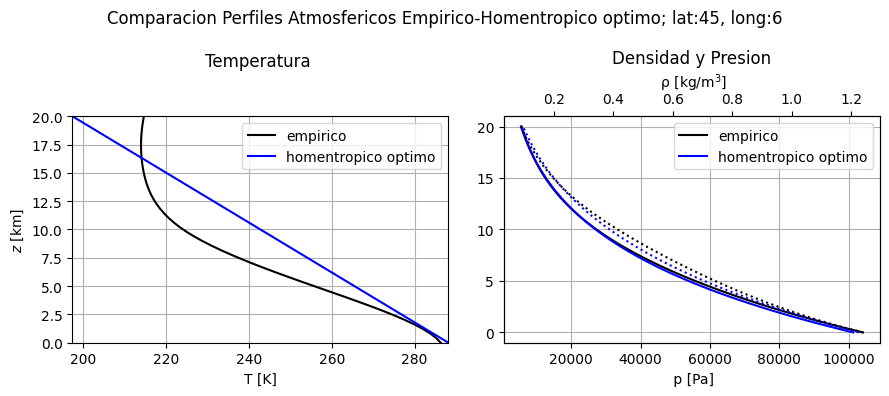

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(9,4))
fig.suptitle(f'Comparacion Perfiles Atmosfericos Empirico-Homentropico optimo; lat:{lat}, long:{lon}')

h2_opt = γ_opt/(γ_opt-1)*ho_opt
Ts_hom = To*(1-z/h2_opt)
ρs_hom = ρo*(1-z/h2_opt)**(1/(γ_opt-1))
ps_hom = po*(1-z/h2_opt)**(γ_opt/(γ_opt-1))


ax[0].plot(Ts_emp, z/1e3, 'k', label='empirico')
ax[0].plot(Ts_hom, z/1e3, 'b', label='homentropico optimo')
ax[0].set_title("Temperatura \n\n")
ax[0].set_ylabel(r"$z$ [km]")
ax[0].set_xlabel(r"T [K]")
ax[0].legend()
ax[0].grid()
ax[0].margins(0)

ax[1].plot(p_emp, z/1e3, 'k', label='empirico')
ax[1].plot(ps_hom, z/1e3, 'b', label='homentropico optimo')
ax[1].set_title(r"Densidad y Presion")
ax[1].set_xlabel(r" p [Pa]")
ax[1].legend()
ax[1].grid()
axd = ax[1].twiny()
axd.plot(ρs_emp, z/1e3, 'k:')
axd.plot(ρs_hom, z/1e3, 'b:')
axd.set_xlabel(r" ρ [kg/m$^3$]")


fig.tight_layout()

la calidad del ajuste en los campos de densidad y presion del modelo homentropico con los nuevos parametros optimos es muy buena, se ajusta casi muy bien a los valores empiricos, con una leve diferencia en las densidades, que son un poco mayores las del modelo empirico en la region media, cercana a los 10km. la temperatura si es mas dificil que se ajuste, pues el modelo homentropico para la temperatura es lineal, distinto a la curva empirica

### **Mapas de los parametros $(h_o, γ, T_o)$**

7. Repita el procedimiento anterior para muchos puntos en la superficie de la Tierra y haga mapas de $h_0$, $\gamma$ y $T_0$ sobre la superficie del planeta. Comente los resultados que obtiene.

En este caso, debido a la minimizacion de la funcion χ cuadrado, no se pudo aprovechar el for implicito como en los puntos anteriores para la longitud, por lo que se


In [ ]:
hos = np.zeros_like(LONS)
Tos = np.zeros_like(LONS)
gammas = np.zeros_like(LONS)

z = np.linspace(0, 20e3, 50) # [m]

for i,lat_i in tqdm(enumerate(lats)): # sobre latitudes

  for j,lon_j in enumerate(lons):     # sobre longitudes

    # objeto atmosferico
    ds_tropo = msise_4d( datetime(2000,4,23,12,0,0), z/1e3, lat_i, lon_j )
    ρs_emp = np.array(ds_tropo["rho"]).flatten()*1e3 # densidad [kg/m^3]
    Ts_emp = np.array(ds_tropo["Talt"]).flatten() # temperatura [k]
    p_emp = (R/Mmol)*ρs_emp*Ts_emp # presion [Pa]

    result = minimize(chi_cuadrado, initial_guess)
    hos[i][j], gammas[i][j], Tos[i][j] = result.x


15it [04:11, 16.78s/it]


#### **mapas de los parametros ajustados**

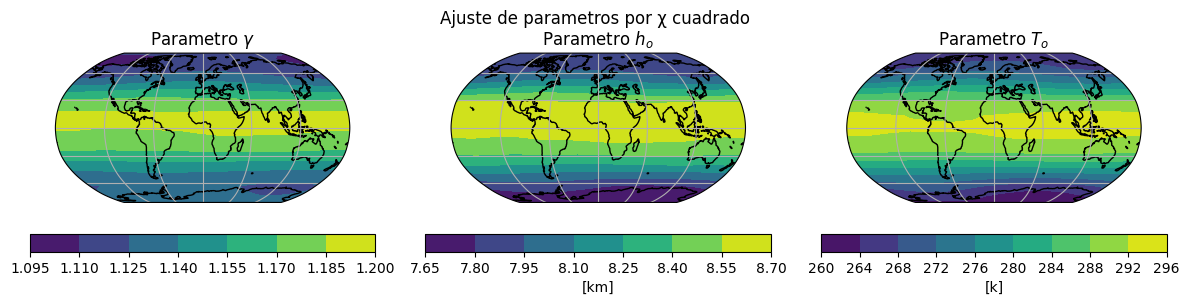

In [ ]:
fig, ax = plt.subplots(1,3,figsize=(12,3),
                       subplot_kw={'projection':ccrs.Robinson()})
fig.suptitle('Ajuste de parametros por χ cuadrado')

# parametro gamma
ax[0].set_title(r'Parametro $\gamma$')
ax[0].coastlines()
ax[0].gridlines()
contour1 = ax[0].contourf(LONS, LATS, gammas,
             transform=ccrs.PlateCarree(),
             cmap='viridis')
cbar = plt.colorbar(contour1, ax=ax[0], orientation='horizontal')

# parametro ho
ax[1].set_title(r'Parametro $h_o$')
ax[1].coastlines()
ax[1].gridlines()
contour2 = ax[1].contourf(LONS, LATS, hos/1e3,
             transform=ccrs.PlateCarree(),
             cmap='viridis')
cbar = plt.colorbar(contour2, ax=ax[1], orientation='horizontal')
cbar.set_label('[km]')

# parametro To
ax[2].set_title(r'Parametro $T_o$')
ax[2].coastlines()
ax[2].gridlines()
contour2 = ax[2].contourf(LONS, LATS, Tos,
             transform=ccrs.PlateCarree(),
             cmap='viridis')
cbar = plt.colorbar(contour2, ax=ax[2], orientation='horizontal')
cbar.set_label('[k]')
plt.tight_layout()

Un resultado inmediato es el del mejor ajuste de la temperatura superficial, que en el mes de abril tiende a ser mayor en la region del ecuador, la altura $h_o$ tambien se podria relacionar con la altura de la troposfera, como en general esta es mas alta en el ecuador es esperable que la altura hipotetica $h_o$ tambien sea mayor en esta region.

Hay varios facores que influyen en que la troposfera sea mas alta en la region ecuatorial a diferencia de los polos, entre las que estan la mayor incidencia de radiacion solar, la rotacion terrestre y los procesos convectivos de aire que ocurren en la troposfera.



**Resultados esperados**:

- Este notebook con el procedimiento debidamente comentado.

- Gráficos mínimos:
  - Gráficos de cada punto.

- Datos mínimos:
  - Los números solicitados en cada punto.

- En caso de utilizar ayudas como `ChatGPT` o códigos de `Stack Over Flow` debe citar debidamente la fuente, pero también entender a cabalidad el código, el profesor puede pedir justificación.

## ¿Cómo hacer mapas con `cartopy`

El paquete `cartopy` es el _standard de facto_ para hacer mapas con `matplotlib`. Aquí encuentra la documentación: https://scitools.org.uk/cartopy/docs/v0.5/index.html.

In [ ]:
# !pip install -Uq cartopy

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs

# ax = plt.axes(projection = ccrs.Robinson())
# ax.set_global()
# ax.coastlines()
# ax.gridlines()

# lats = np.linspace(-90, 90, 10)
# lons = np.linspace(-180, 180, 10)
# LONS, LATS = np.meshgrid(lons,lats)
# data = LONS/15

# plt.contourf(LONS, LATS, data, transform=ccrs.PlateCarree(),
#              levels=24,cmap='prism')

# cbar = plt.colorbar(orientation='horizontal')
# cbar.set_label('Diferencia horaria respecto a Greenwich [h]')